In [2]:
import os
os.chdir('../../../../..')

In [3]:
from src.datasets import MaterialsProject

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids
from hdbscan import HDBSCAN
from src.helper_functions import evaluate_hdbscan_grid
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from src.helper_functions import create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [5]:
mp = MaterialsProject(limit=5000, sampling_strategy="stratified", stratify_on=["band_gap", "energy_above_hull"], descriptors=["soap"])
df = mp.load()

2026-05-05 10:31:57.924 | INFO     | src.datasets:load:1998 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-05-05 10:31:58.789 | INFO     | src.datasets:_add_descriptors:2371 - Ignoring output_tag=sample_n6000_seed40_stratified since descriptors are attached directly to dataframe.
2026-05-05 10:31:58.789 | INFO     | src.datasets:_add_descriptors:2375 - Extracting unique elements from formulas...
2026-05-05 10:31:58.814 | INFO     | src.datasets:_add_descriptors:2383 - Found 86 unique elements.
2026-05-05 10:31:58.823 | INFO     | src.datasets:_add_descriptors:2444 - Computing SOAP chunk 0 (0 to 1000, normalize=True)...
2026-05-05 10:32:02.015 | INFO     | src.datasets:_add_descriptors:2444 - Computing SOAP chunk 1 (1000 to 2000, normalize=True)...
2026-05-05 10:32:05.635 | INFO     | src.datasets:_add_descriptors:2444 - Computing SOAP chunk 2 (2000 to 3000, normalize=True)...
2026-05-05 10:32:09.358 | INFO     | src.datasets:_add_descriptors:24

In [5]:
print(np.array(df["soap_embedding"].to_list()[0]).shape)

(252,)


In [6]:
dist_type = "soap_kernel"
dist_matrix = mp.get_distance_matrix(
    descriptor="soap",
    dist_type=dist_type,
    force_calculate=True,
)

2026-05-05 10:32:27.106 | INFO     | src.datasets:get_distance_matrix:2776 - Calculating distance matrix for soap using soap_kernel distance.
2026-05-05 10:32:27.436 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/Materials Project/dist_soap_soap_kernel.npy


# Hierarchical Clustering on Distance Matrix

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_49771/1931524682.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist_matrix, method='average')


(array([1, 2, 3, 4], dtype=int32), array([   2,    5, 4838,  155]))


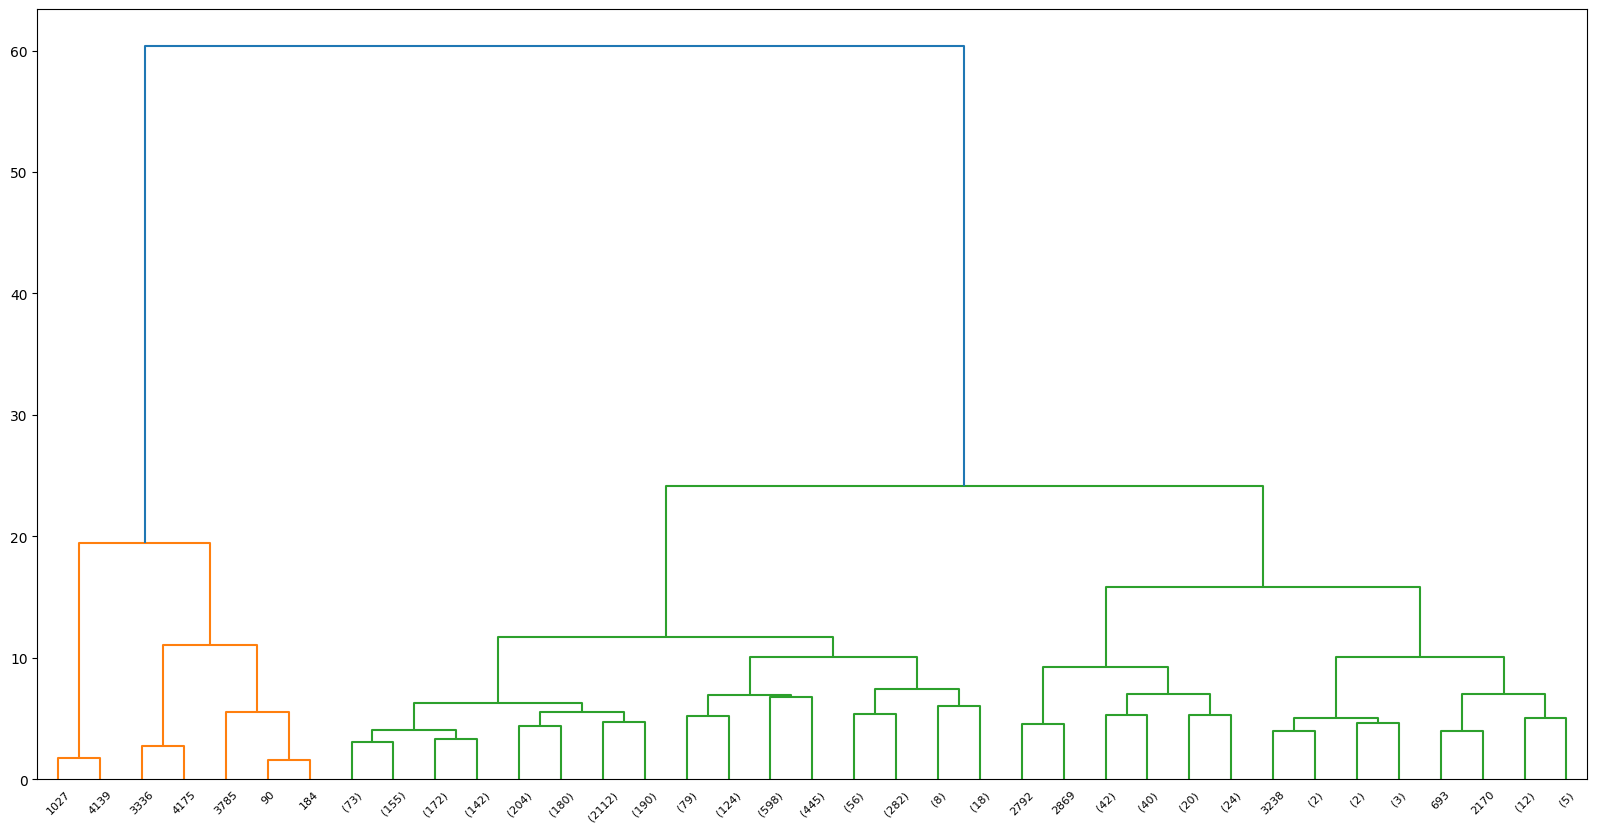

In [7]:
link = linkage(dist_matrix, method='average')
plt.figure(figsize=(20,10))
l=dendrogram(link, p=5, truncate_mode='level')
labels_hier = fcluster(link, t=18, criterion='distance')
df = df.with_columns(labels_hier=labels_hier)
print(np.unique(labels_hier, return_counts=True))

In [8]:
d = average_numeric_by_cluster(df, "labels_hier")

shape: (4, 35)
┌─────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬─────────┬─────────┬─────────┬──────────┬─────────┬─────────┬───────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┬───────────────────────────┬──────────────────────┬──────────────────────────┐
│ labels_hier ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a       ┆ b       ┆ c       ┆ alpha    ┆ beta    ┆ gamma   ┆ volume    ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ is_injected ┆ pct_metal ┆ unique_crystal_systems ┆ top_crystal_system ┆ top_crystal_system_pct ┆ uniqu

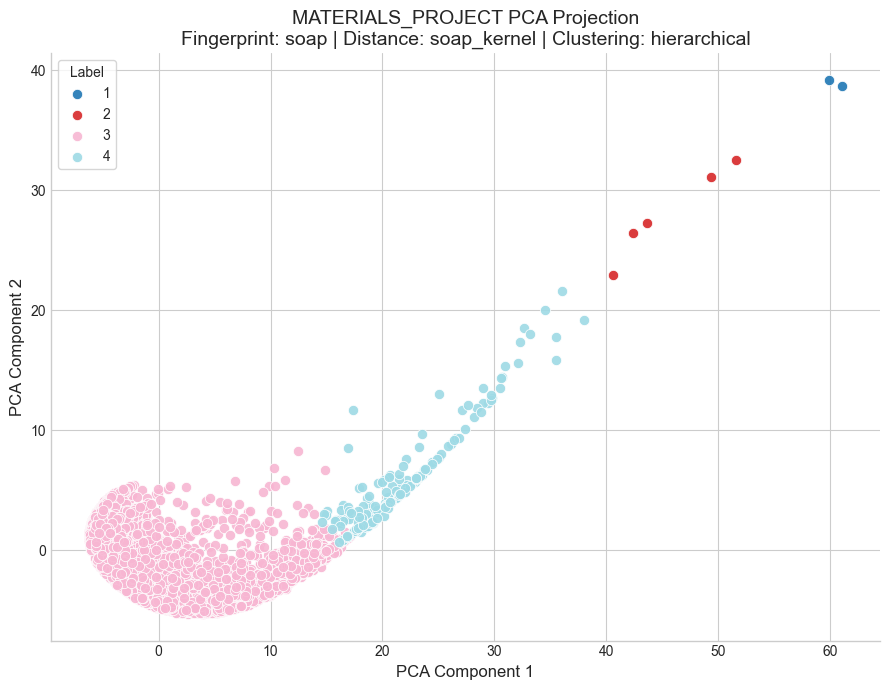

2026-04-27 17:29:14.103 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/materials_project/clustering/soap_kernel/soap/pca_hierarchical_projection.png


In [9]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_hier,
    clustering_method="hierarchical"
)

In [10]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

2026-04-27 17:29:14.118 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-27 17:29:14.119 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-27 17:29:16.225 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-27 17:29:16.229 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-27 17:29:16.708 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: materials_PCA_clustering.json
2026-04-27 17:29:16.826 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

# KMedoids

In [11]:
model_km = KMedoids(n_clusters=4, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
print(np.unique(labels_km, return_counts=True))
df = df.with_columns(labels_km=labels_km)

(array([0, 1, 2, 3], dtype=uint64), array([2482,  998,  868,  652]))


In [12]:
d = average_numeric_by_cluster(df, "labels_km")

shape: (4, 36)
┌───────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬─────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬─────────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┬───────────────────────────┬──────────────────────┬──────────────────────────┐
│ labels_km ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c       ┆ alpha   ┆ beta    ┆ gamma   ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ is_injected ┆ labels_hier ┆ pct_metal ┆ unique_crystal_systems ┆ top_crystal_system ┆ top_crystal_sy

In [13]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

2026-04-27 17:29:17.274 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-27 17:29:17.274 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-27 17:29:19.657 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-27 17:29:19.662 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-27 17:29:20.108 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: materials_PCA_clustering.json
2026-04-27 17:29:20.228 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

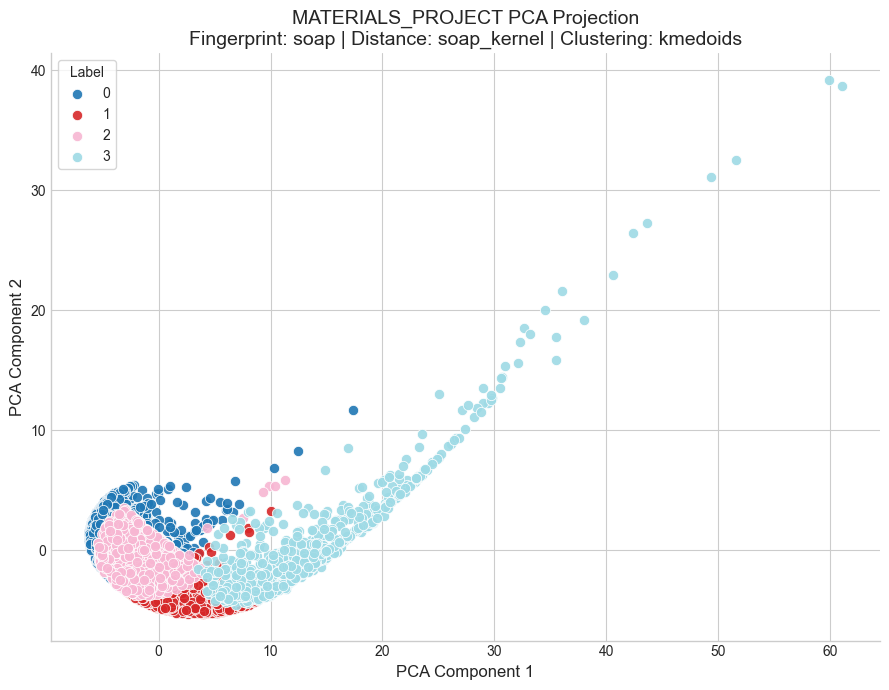

2026-04-27 17:29:20.767 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/materials_project/clustering/soap_kernel/soap/pca_kmedoids_projection.png


In [14]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_km,
    clustering_method="kmedoids"
)

# Spectral

In [15]:
gaussian_kernel = np.exp(-dist_matrix**2 / (2 * np.std(dist_matrix)**2))

kernel_matrix = 1.0 - (dist_matrix**2 / 2.0)

# 2. Clean up numerical noise (highly recommended after saving/loading matrices)
# The kernel similarity of a molecule/environment with itself must be exactly 1
np.fill_diagonal(kernel_matrix, 1.0)

# Ensure values strictly remain within the valid [0, 1] range for a normalized kernel
kernel_matrix = np.clip(kernel_matrix, a_min=0.0, a_max=1.0)

# Force strict symmetry in case floating point drift made it slightly asymmetric
kernel_matrix = (kernel_matrix + kernel_matrix.T) / 2.0

In [16]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(kernel_matrix)
df = df.with_columns(labels_spectral=labels_spectral)

In [18]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

2026-05-07 08:16:08.018 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 08:16:08.019 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:16:10.216 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:16:10.288 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:16:13.512 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: materials_PCA_clustering.json
2026-05-07 08:16:13.658 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

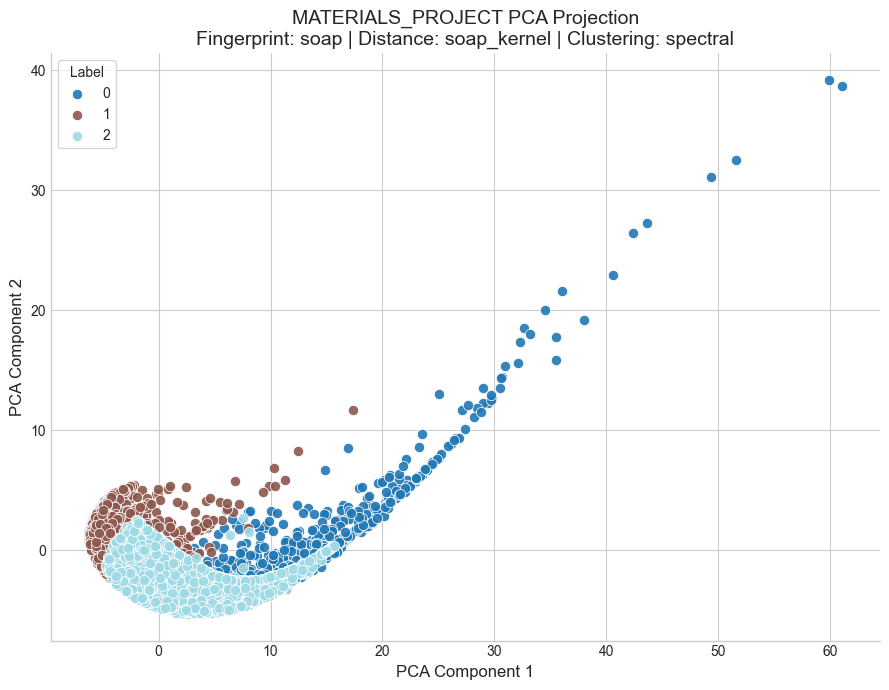

2026-05-07 08:16:00.054 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/materials_project/clustering/soap_kernel/soap/pca_spectral_projection.png


{'coords': array([[ 1.5128511, -4.6238008],
        [-5.6782613,  2.6976826],
        [-2.8700395,  3.2916148],
        ...,
        [-4.71041  ,  1.8610176],
        [-4.385312 ,  1.490091 ],
        [-5.286017 ,  1.4792777]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/materials_project/clustering/soap_kernel/soap/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/materials_project/clustering/soap_kernel/soap'),
 'clustering_method': 'spectral'}

In [17]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_spectral,
    clustering_method="spectral"
)

In [ ]:
average_numeric_by_cluster(df, "labels_spectral")

# DBSCAN

In [ ]:
model_db = DBSCAN(
    eps=0.3,
    min_samples=4,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db,return_counts=True))

(array([-1,  0,  1]), array([  30, 4965,    5]))


In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-21 09:37:06.554 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/materials_project/clustering/soap_kernel/soap/pca_dbscan_projection.png


{'coords': array([[ 69.452576 ,  -5.534922 ],
        [ 74.658104 ,   4.7394447],
        [-43.155144 ,   2.4004843],
        ...,
        [-43.00159  ,   2.7514362],
        [-43.048145 ,   2.9704266],
        [-43.03756  ,   2.9792025]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/materials_project/clustering/soap_kernel/soap/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/materials_project/clustering/soap_kernel/soap'),
 'clustering_method': 'dbscan'}

In [ ]:
average_numeric_by_cluster(df, "labels_db")

shape: (3, 33)
┌───────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┐
│ labels_db ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c      ┆ alpha   ┆ beta    ┆ gamma   ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ labels_hier ┆ labels_km ┆ pct_metal ┆ unique_crystal_systems ┆ top_crystal_system ┆ top_crystal_system_pct ┆ unique_space_groups ┆ top_space_group ┆ top_space_group_pct ┆ unique_anon

labels_db,count,max_en_diff,energy_per_atom,formation_energy_per_atom,band_gap,density,a,b,c,alpha,beta,gamma,volume,num_sites,energy_above_hull,avg_bond_length,max_bond_length,labels_hier,labels_km,pct_metal,unique_crystal_systems,top_crystal_system,top_crystal_system_pct,unique_space_groups,top_space_group,top_space_group_pct,unique_anonymized_formulas,top_anonymized_formula,top_anonymized_formula_pct,unique_pearson_symbols,top_pearson_symbol,top_pearson_symbol_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,30,1.26,-15.746711,-1.005518,0.39667,7.007539,6.150398,6.841861,9.580807,94.868577,94.66132,84.860065,351.088311,19.766667,0.05238,2.387351,2.646118,1.8,1.466667,73.333333,7,"""Tetragonal""",30.0,25,"""Pm-3m""",6.666667,24,"""ABC2""",10.0,25,"""tI10""",13.333333
0,4965,1.57429,-13.542779,-1.293601,0.50577,6.232223,6.800731,7.239713,9.506849,86.692882,87.251411,88.64918,426.997715,25.775428,0.083935,2.304561,2.577566,1.366566,1.403424,60.60423,7,"""Orthorhombic""",21.490433,174,"""P1""",8.922457,991,"""ABC2""",5.800604,644,"""cF16""",3.222558
1,5,0.488,-22.176113,-0.50146,0.02546,6.011968,5.855352,6.575726,8.429758,80.768057,80.089095,91.138311,300.477952,10.4,0.00765,2.648671,2.873014,1.0,1.0,40.0,3,"""Monoclinic""",40.0,5,"""P-4m2""",20.0,5,"""AB3C4D8""",20.0,5,"""tP4""",20.0


# HDBSCAN

In [ ]:
d = evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=300, ms=1, clusters=2, noise=0.57, persistence=0.168, score=0.072
mcs=150, ms=15, clusters=2, noise=0.64, persistence=0.157, score=0.057
mcs=120, ms=1, clusters=6, noise=0.65, persistence=0.149, score=0.053
mcs=150, ms=1, clusters=3, noise=0.53, persistence=0.108, score=0.051
mcs=220, ms=1, clusters=3, noise=0.53, persistence=0.106, score=0.050
mcs=80, ms=1, clusters=7, noise=0.69, persistence=0.153, score=0.047
mcs=150, ms=10, clusters=2, noise=0.70, persistence=0.149, score=0.045
mcs=220, ms=10, clusters=2, noise=0.70, persistence=0.130, score=0.039
mcs=80, ms=40, clusters=2, noise=0.37, persistence=0.055, score=0.035
mcs=80, ms=40, clusters=2, noise=0.37, persistence=0.055, score=0.035
mcs=60, ms=60, clusters=2, noise=0.34, persistence=0.050, score=0.033
mcs=220, ms=22, clusters=2, noise=0.73, persistence=0.116, score=0.032
mcs=120, ms=10, clusters=4, noise=0.79, persistence=0.146, score=0.031
mcs=300, ms=10, clusters=2, noise=0.70, persistence=0.101, score

In [10]:
hdb = HDBSCAN(min_cluster_size=60, min_samples=60, metric='precomputed')
hbdscan_labels = hdb.fit_predict(dist_matrix.astype(np.float64))

In [11]:
create_chemiscope_viewer(df, dist_matrix, hbdscan_labels, 'PCA')

2026-05-05 10:32:47.493 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-05 10:32:47.494 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-05 10:32:49.114 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-05 10:32:49.119 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-05 10:32:49.517 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: materials_PCA_clustering.json
2026-05-05 10:32:49.678 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

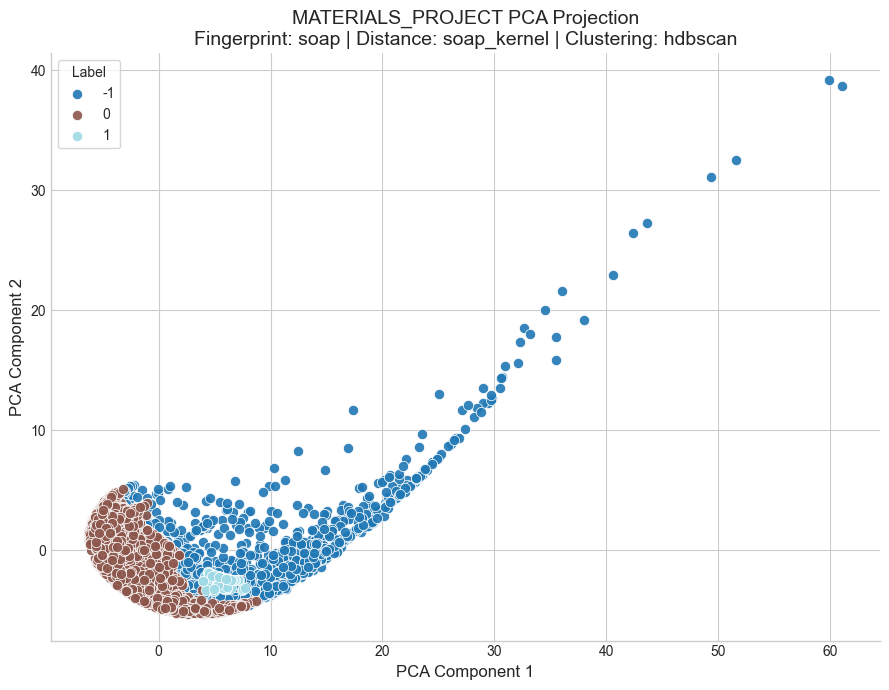

2026-04-27 17:30:58.490 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/materials_project/clustering/soap_kernel/soap/pca_hdbscan_projection.png


In [19]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="materials_project",
    labels=hbdscan_labels,
    clustering_method="hdbscan"
)

# KMeans on Raw Embeddings

In [ ]:
X_raw = np.array(df["soap_embedding"].to_list(), dtype=np.float32)
kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans_raw = kmeans_raw.fit_predict(X_raw)
df = df.with_columns(labels_kmeans_raw=labels_kmeans_raw)

NameError: name 'np' is not defined

In [ ]:
create_chemiscope_viewer(df, X_raw, labels_kmeans_raw, 'PCA')

In [ ]:
average_numeric_by_cluster(df, "labels_kmeans_raw")